## this notebook was ran on google colab because I trained the model on GPA T4 instead of CPU, then I saved it and completed my work on vscode

## Import liabraries, load data and check Hardware

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from datasets import Dataset, DatasetDict

from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer)

from peft import (LoraConfig, TaskType, get_peft_model)

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU Memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB


In [ ]:
df = pd.read_csv(r"/content/MovieReviewTrainingDatabase.csv", engine='python', on_bad_lines='skip')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10261, 2)


,sentiment,review
0,Positive,With all this stuff going down at the moment w...
1,Positive,'The Classic War of the Worlds' by Timothy Hin...
2,Negative,The film starts with a manager (Nicholas Bell)...
3,Negative,It must be assumed that those who praised this...
4,Positive,Superbly trashy and wondrously unpretentious 8...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  10261 non-null  object
 1   review     10261 non-null  object
dtypes: object(2)
memory usage: 160.5+ KB


In [ ]:
df.isnull().sum()

,0
sentiment,0
review,0


In [ ]:
print(df["sentiment"].value_counts())

sentiment
Positive    5192
Negative    5069
Name: count, dtype: int64


In [ ]:
df = df.drop_duplicates(subset=["review"])

df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (10236, 2)


In [ ]:
label_mapping = {
    "Negative": 0,
    "Positive": 1
}

df["label"] = df["sentiment"].map(label_mapping)

df.head()

,sentiment,review,label
0,Positive,With all this stuff going down at the moment w...,1
1,Positive,'The Classic War of the Worlds' by Timothy Hin...,1
2,Negative,The film starts with a manager (Nicholas Bell)...,0
3,Negative,It must be assumed that those who praised this...,0
4,Positive,Superbly trashy and wondrously unpretentious 8...,1


In [ ]:
df = df[["review", "label"]]

In [ ]:
# split the data
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 8188
Validation: 1024
Test: 1024


In [ ]:
#convert pandas to hugging face dataset
train_dataset = Dataset.from_pandas(
    train_df[["review", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["review", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["review", "label"]],
    preserve_index=False
)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 8188
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 1024
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 1024
    })
})

In [ ]:
# load distilBERT tokenizer
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
MAX_LENGTH = 256
def tokenize_function(examples):
    return tokenizer(
        examples["review"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [ ]:
tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/8188 [00:00<?, ? examples/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

In [ ]:
# dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
tokenized_dataset = tokenized_dataset.remove_columns(["review"])

In [ ]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8188
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1024
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1024
    })
})


In [ ]:
# lora configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    # Keep the task-specific classification head trainable.
    modules_to_save=["pre_classifier", "classifier"],
    bias="none"
)

In [ ]:
# load distilbert
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import transformers
import torch

print("Transformers version:", transformers.__version__)
print("PyTorch version:", torch.__version__)

Transformers version: 5.16.1
PyTorch version: 2.11.0+cu128


In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    "distilbert-base-uncased"
)

print(config)

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.16.1",
  "vocab_size": 30522
}



In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={
        0: "NEGATIVE",
        1: "POSITIVE"
    },
    label2id={
        "NEGATIVE": 0,
        "POSITIVE": 1
    }
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(model.config.id2label)
print(model.config.label2id)

{0: 'NEGATIVE', 1: 'POSITIVE'}
{'NEGATIVE': 0, 'POSITIVE': 1}


In [ ]:
from peft import LoraConfig, TaskType, get_peft_model

# Upgrade torchao to a compatible version
!pip install --upgrade torchao

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    # Keep the task-specific classification head trainable.
    modules_to_save=["pre_classifier", "classifier"],
    bias="none"
)

model = get_peft_model(
    model,
    lora_config
)

In [ ]:
model.print_trainable_parameters()

trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


### Final dataset/model checks before training

DistilBERT does not use `token_type_ids`, so we remove that field if the tokenizer created it. We also verify that the LoRA model is configured for sequence classification and that the classification head remains trainable.


In [ ]:
# DistilBERT does not require token_type_ids.
for split in tokenized_dataset.keys():
    if "token_type_ids" in tokenized_dataset[split].column_names:
        tokenized_dataset[split] = tokenized_dataset[split].remove_columns(["token_type_ids"])

print(tokenized_dataset)
print("Train columns:", tokenized_dataset["train"].column_names)


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 8188
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1024
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1024
    })
})
Train columns: ['label', 'input_ids', 'attention_mask']


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision = precision_score(
        labels,
        predictions,
        average="binary"
    )

    recall = recall_score(
        labels,
        predictions,
        average="binary"
    )

    f1 = f1_score(
        labels,
        predictions,
        average="binary"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./models/distilbert-lora",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    report_to="none",

    save_total_limit=2
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

## 1. Train the LoRA model

The training timer below measures the actual training duration on the current hardware. Because this notebook is running on CPU in the captured environment, training can be considerably slower than on a CUDA GPU.


In [ ]:
train_start = time.perf_counter()

train_result = trainer.train()

training_time = time.perf_counter() - train_start

print(f"Training time: {training_time / 60:.2f} minutes")


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.639143,0.280742,0.890625,0.876155,0.913295,0.894340
2,0.559280,0.266260,0.897461,0.893536,0.905588,0.899522


Training time: 2.00 minutes


## 2. Evaluate on the validation set

Accuracy, precision, recall, and F1-score are calculated from the model predictions. For this balanced binary sentiment dataset, these metrics provide a useful view of overall and class-specific performance.


In [ ]:
validation_metrics = trainer.evaluate(tokenized_dataset["validation"])
validation_metrics


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.559280,0.266260,2,0.897461,0.893536,0.905588,0.899522


{'eval_loss': 0.26625964045524597,
 'eval_accuracy': 0.8974609375,
 'eval_precision': 0.8935361216730038,
 'eval_recall': 0.905587668593449,
 'eval_f1': 0.8995215311004785}

## 3. Test-set evaluation

The test set is kept separate from training and validation and is used only for the final performance report.


In [ ]:
test_output = trainer.predict(tokenized_dataset["test"])

test_logits = test_output.predictions
test_labels = test_output.label_ids
test_predictions = np.argmax(test_logits, axis=-1)

test_accuracy = accuracy_score(test_labels, test_predictions)
test_precision = precision_score(test_labels, test_predictions, zero_division=0)
test_recall = recall_score(test_labels, test_predictions, zero_division=0)
test_f1 = f1_score(test_labels, test_predictions, zero_division=0)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    test_labels,
    test_predictions,
    target_names=["Negative", "Positive"],
    digits=4,
    zero_division=0
))


Accuracy : 0.8975
Precision: 0.8994
Recall   : 0.8977
F1-score : 0.8986

Classification Report:

              precision    recall  f1-score   support

    Negative     0.8955    0.8972    0.8963       506
    Positive     0.8994    0.8977    0.8986       518

    accuracy                         0.8975      1024
   macro avg     0.8974    0.8975    0.8974      1024
weighted avg     0.8975    0.8975    0.8975      1024



## 4. Confusion Matrix


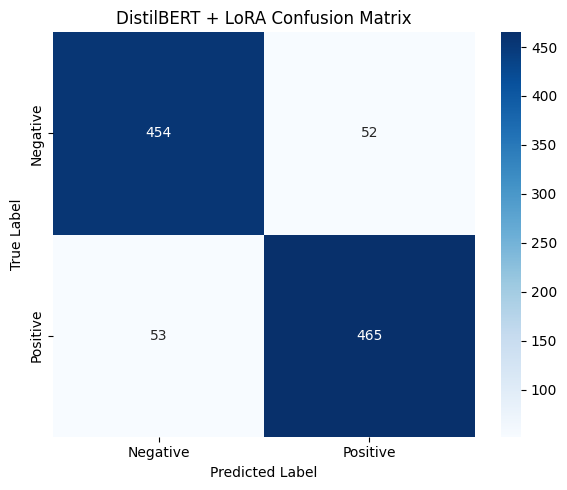

In [ ]:
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DistilBERT + LoRA Confusion Matrix")
plt.tight_layout()
plt.show()


## 5. Number of trainable parameters

LoRA freezes the pretrained DistilBERT weights and adds small low-rank trainable matrices to the selected attention projections. This greatly reduces the number of parameters that receive gradient updates.


In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
frozen_params = all_params - trainable_params

print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters   : {frozen_params:,}")
print(f"Total parameters    : {all_params:,}")
print(f"Trainable percentage: {100 * trainable_params / all_params:.4f}%")


Trainable parameters: 739,586
Frozen parameters   : 66,955,010
Total parameters    : 67,694,596
Trainable percentage: 1.0925%


In [ ]:
MODEL_DIR = "./distilbert-lora-imdb"

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("Saved to:", MODEL_DIR)

Saved to: ./distilbert-lora-imdb


In [ ]:
!zip -r distilbert-lora-imdb.zip distilbert-lora-imdb

  adding: distilbert-lora-imdb/ (stored 0%)
  adding: distilbert-lora-imdb/tokenizer.json (deflated 71%)
  adding: distilbert-lora-imdb/README.md (deflated 66%)
  adding: distilbert-lora-imdb/tokenizer_config.json (deflated 43%)
  adding: distilbert-lora-imdb/adapter_model.safetensors (deflated 7%)
  adding: distilbert-lora-imdb/adapter_config.json (deflated 60%)
  adding: distilbert-lora-imdb/training_args.bin (deflated 53%)


In [ ]:
from google.colab import files

files.download("distilbert-lora-imdb.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>